In [ ]:
print("hello")
!pip3 install pandas

hello


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 16 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      439140 non-null  int64  
 1   Driver                  439140 non-null  object 
 2   Compound                439140 non-null  object 
 3   Race                    439140 non-null  object 
 4   Year                    439140 non-null  int64  
 5   PitStop                 439140 non-null  int64  
 6   LapNumber               439140 non-null  int64  
 7   Stint                   439140 non-null  int64  
 8   TyreLife                439140 non-null  float64
 9   Position                439140 non-null  int64  
 10  LapTime (s)             439140 non-null  float64
 11  LapTime_Delta           439140 non-null  float64
 12  Cumulative_Degradation  439140 non-null  float64
 13  RaceProgress            439140 non-null  float64
 14  Position_Change     

In [ ]:
train.iloc[0:5,1:9]

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0


In [ ]:
train.iloc[0:5,9:]

,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,2,107.878,8.965,-14.139,0.361111,3.0,0.0


In [ ]:
train.PitNextLap.value_counts()

,count
PitNextLap,
0.0,351759
1.0,87381


In [ ]:
X_features = list(train.columns)
X_features.remove('PitNextLap')
# X_features.remove('PitStop')
X_features.remove('Year')
X_features.remove('LapNumber')
X_features.remove('Race')
X_features.remove('Driver')
X_features.remove('id')

In [ ]:
X_features

['Compound',
 'PitStop',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change']

In [ ]:
encoded_train = pd.get_dummies(train[X_features],drop_first=True)
encoded_test = pd.get_dummies(test[X_features], drop_first=True)

In [ ]:
list(encoded_train.columns)

['PitStop',
 'Stint',
 'TyreLife',
 'Position',
 'LapTime (s)',
 'LapTime_Delta',
 'Cumulative_Degradation',
 'RaceProgress',
 'Position_Change',
 'Compound_INTERMEDIATE',
 'Compound_MEDIUM',
 'Compound_SOFT',
 'Compound_WET']

In [ ]:
import statsmodels.api as sm
Y = train.PitNextLap
X = sm.add_constant(encoded_train)

In [ ]:
Y = train.PitNextLap
X = sm.add_constant(encoded_train)

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2, random_state=42)

In [ ]:
# from xgboost import XGBClassifier
# from sklearn.metrics import roc_auc_score

# model = XGBClassifier(
#     n_estimators=500,
#     learning_rate=0.05,       # how much each tree contributes
#     max_depth=6,              # shallow trees work best
#     subsample=0.8,            # random row sampling per tree
#     colsample_bytree=0.8,     # random feature sampling per tree
#     scale_pos_weight=5,       # handles pit stop class imbalance
#     eval_metric='auc',
#     random_state=42
# )

# model.fit(
#     X_train, Y_train,
#     eval_set=[(X_test, Y_test)],
#     verbose=50                # prints AUC every 50 trees
# )

# Y_prob = model.predict_proba(X_test)[:, 1]
# print("ROC-AUC:", roc_auc_score(Y_test, Y_prob))



[0]	validation_0-auc:0.89016
[50]	validation_0-auc:0.91699
[100]	validation_0-auc:0.92526
[150]	validation_0-auc:0.92921
[200]	validation_0-auc:0.93183
[250]	validation_0-auc:0.93325
[300]	validation_0-auc:0.93447
[350]	validation_0-auc:0.93526
[400]	validation_0-auc:0.93589
[450]	validation_0-auc:0.93644
[499]	validation_0-auc:0.93683
ROC-AUC: 0.9368289062457597


In [ ]:
!pip install lightgbm

In [ ]:
from lightgbm import LGBMClassifier
import lightgbm as lgb
from sklearn.metrics import roc_auc_score

model = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=63,            # key param — controls tree complexity
    min_child_samples=50,     # min samples per leaf, prevents overfit
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=4,       # pit stops are minority class
    random_state=42,
    n_jobs=-1
)
# Before fit, clean column names
X_train.columns = X_train.columns.str.replace(' ', '_')
X_test.columns  = X_test.columns.str.replace(' ', '_')

model.fit(
    X_train, Y_train,
    eval_set=[(X_test, Y_test)],
    callbacks=[lgb.early_stopping(300), lgb.log_evaluation(300)]
)

Y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(Y_test, Y_prob))

[LightGBM] [Info] Number of positive: 69839, number of negative: 281473
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.071040 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1174
[LightGBM] [Info] Number of data points in the train set: 351312, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.198795 -> initscore=-1.393844
[LightGBM] [Info] Start training from score -1.393844
Training until validation scores don't improve for 300 rounds
[300]	valid_0's binary_logloss: 0.321538
Did not meet early stopping. Best iteration is:
[500]	valid_0's binary_logloss: 0.315526
ROC-AUC: 0.9392630495052491


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(Y_test, model.predict(X_test)))
cm = confusion_matrix(Y_test, model.predict(X_test))
print("Confusion Matrix:")
print(cm)

              precision    recall  f1-score   support

         0.0       0.97      0.85      0.91     70286
         1.0       0.60      0.89      0.72     17542

    accuracy                           0.86     87828
   macro avg       0.79      0.87      0.81     87828
weighted avg       0.90      0.86      0.87     87828

Confusion Matrix:
[[59875 10411]
 [ 1845 15697]]


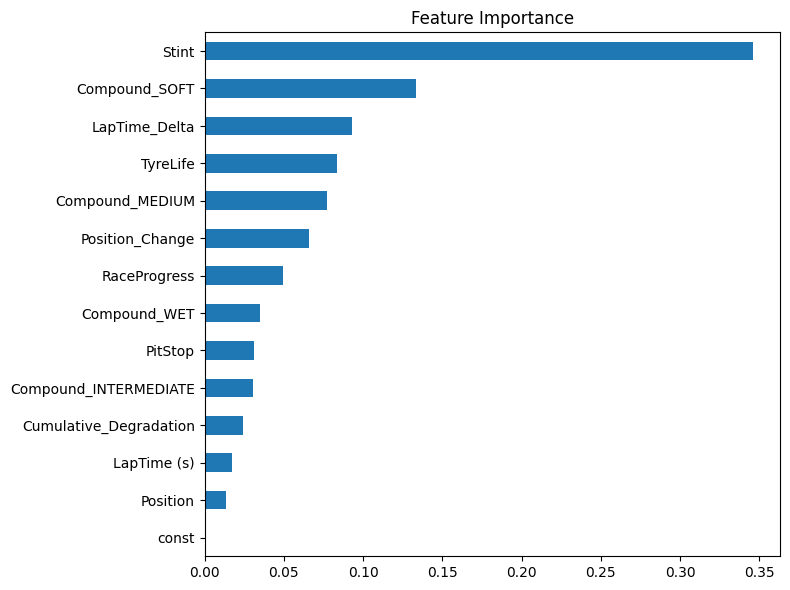

In [ ]:
# Feature importance (most useful for F1 analysis)
import pandas as pd
import matplotlib.pyplot as plt

importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=True).plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

<Axes: >

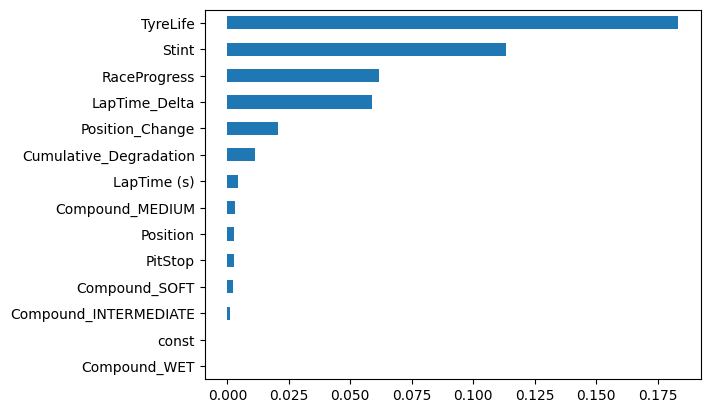

In [ ]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model, X_test, Y_test, n_repeats=10, random_state=42)
perm_imp = pd.Series(result.importances_mean, index=X.columns)
perm_imp.sort_values(ascending=True).plot(kind='barh')

In [ ]:
import csv
import pandas as pd

# Get probabilities from your model
X_test = sm.add_constant(encoded_test)
Y_prob = model.predict_proba(X_test)[:, 1]

# Create submission dataframe
submission = pd.DataFrame({
    'id': test['id'],        # ← replace 'id' with your actual id column name
    'PitNextLap': Y_prob
})

# Save to csv
submission.to_csv('submission.csv', index=False)

print(submission.head())
print(f"Submission shape: {submission.shape}")

       id  PitNextLap
0  439140    0.013106
1  439141    0.009460
2  439142    0.010797
3  439143    0.366542
4  439144    0.876655
Submission shape: (188165, 2)
